# GitSkills Dataset Exploration and Exploratory Analysis

Explore the GitSkills dataset to understand its structure, data quality, distributions, and characteristics relevant to the research question.

### Project Imports

In [3]:
import os
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Set Variables

In [9]:
DEFAULT_DB_PATH = Path(r"C:\data\duckdb\agent_skills_release.db")

DB_PATH = Path(
    os.environ.get("GITSKILLS_DB", DEFAULT_DB_PATH)
)

### Locate Database

In [5]:
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

print(f"Database: {DB_PATH}")
print(f"Size: {DB_PATH.stat().st_size / 1024**3:.2f} GB")

Database: C:\data\duckdb\agent_skills_release.db
Size: 36.91 GB


### Connect to DuckDB

In [187]:
conn = duckdb.connect(database=str(DB_PATH), read_only=True)
duckdb_version = conn.sql("""select version()""").fetchall()[0][0]

print(f"Connected to DuckDB version {duckdb_version}")

Connected to DuckDB version v1.5.5


### Examine Database

In [188]:
conn.sql("show tables").show()

┌───────────────────┐
│       name        │
│      varchar      │
├───────────────────┤
│ artifact_siblings │
│ artifacts         │
│ mining_runs       │
│ repos             │
└───────────────────┘



In [189]:
conn.sql("""
    SELECT
        database_name,
        database_size,
        block_size,
        total_blocks,
        used_blocks,
        free_blocks,
        wal_size
    FROM pragma_database_size()
""").df()

,database_name,database_size,block_size,total_blocks,used_blocks,free_blocks,wal_size
0,agent_skills_release,36.9 GiB,262144,151201,151201,0,2.1 MiB


In [190]:
conn.sql("""
    install table_inspector from community;
    load table_inspector;
""")

conn.sql("""
    select * from inspect_block_usage()
""").df()

,component,size_bytes,percentage,block_count
0,table_data,39636434944,100.0%,151201
1,index,0,0.0%,0
2,metadata,0,0.0%,0
3,free_blocks,0,0.0%,0
4,total,39636434944,100.0%,151201


In [191]:
tables = [
    "artifact_siblings",
    "artifacts",
    "mining_runs",
    "repos",
]

block_size = conn.sql("""
    SELECT block_size
    FROM pragma_database_size()
    WHERE database_name != 'memory'
    LIMIT 1
""").fetchall()[0][0]

table_stats = []

for table in tables:
    row_count = conn.sql(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchall()[0][0]

    block_count = conn.sql(f"""
        WITH blocks AS (

            -- Primary segment blocks
            SELECT block_id
            FROM pragma_storage_info('{table}')
            WHERE persistent = TRUE
              AND block_id IS NOT NULL

            UNION

            -- Overflow/additional blocks
            SELECT UNNEST(additional_block_ids) AS block_id
            FROM pragma_storage_info('{table}')
            WHERE persistent = TRUE
        )
        SELECT COUNT(DISTINCT block_id)
        FROM blocks
        WHERE block_id IS NOT NULL
    """).fetchall()[0][0]

    size_bytes = block_count * block_size

    table_stats.append({
        "table": table,
        "rows": row_count,
        "blocks": block_count,
        "size_bytes": size_bytes,
    })

table_stats = pd.DataFrame(table_stats)

table_stats["size_mb"] = table_stats["size_bytes"] / 1024**2
table_stats["size_gb"] = table_stats["size_bytes"] / 1024**3

table_stats

,table,rows,blocks,size_bytes,size_mb,size_gb
0,artifact_siblings,7264865,92424,24228397056,23106.0,22.564453
1,artifacts,3797117,58684,15383658496,14671.0,14.327148
2,mining_runs,7,0,0,0.0,0.000000
3,repos,282200,96,25165824,24.0,0.023438


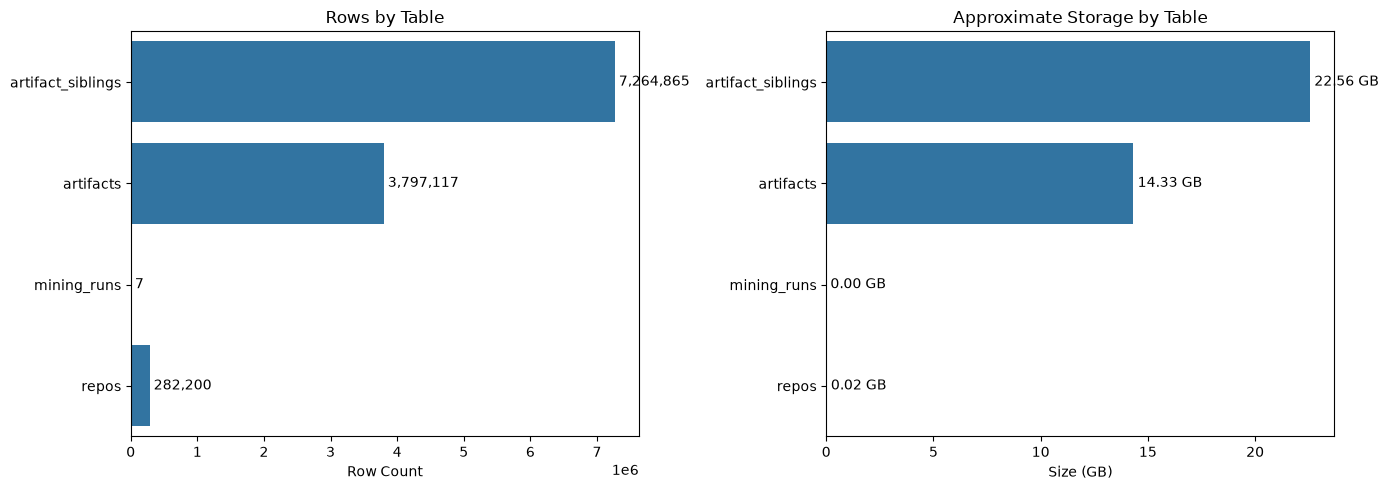

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Row counts
sns.barplot(
    data=table_stats,
    y="table",
    x="rows",
    ax=axes[0]
)

axes[0].set_title("Rows by Table")
axes[0].set_xlabel("Row Count")
axes[0].set_ylabel("")

# Storage sizes
sns.barplot(
    data=table_stats,
    y="table",
    x="size_gb",
    ax=axes[1]
)

axes[1].set_title("Approximate Storage by Table")
axes[1].set_xlabel("Size (GB)")
axes[1].set_ylabel("")

# Labels on bars
for container in axes[0].containers:
    labels = [
        f"{bar.get_width():,.0f}"
        for bar in container
    ]
    axes[0].bar_label(container, labels=labels, padding=3)

for container in axes[1].containers:
    labels = [
        f"{bar.get_width():,.2f} GB"
        for bar in container
    ]
    axes[1].bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

## Data Exploration

### 1. Dataset Overview

Summarize the database, its tables, row counts, and the structure of the `artifacts` table.

In [193]:
table_counts = conn.sql("""
    SELECT 'artifacts' AS table_name, COUNT(*) AS row_count FROM artifacts
    UNION ALL
    SELECT 'artifact_siblings', COUNT(*) FROM artifact_siblings
    UNION ALL
    SELECT 'repos', COUNT(*) FROM repos
    UNION ALL
    SELECT 'mining_runs', COUNT(*) FROM mining_runs
    ORDER BY row_count DESC
""").df()

display(table_counts)

,table_name,row_count
0,artifact_siblings,7264865
1,artifacts,3797117
2,repos,282200
3,mining_runs,7


In [194]:
conn.sql("describe artifacts").df()

,column_name,column_type,null,key,default,extra
0,repo_full_name,VARCHAR,YES,None,None,None
1,path,VARCHAR,YES,None,None,None
2,filename,VARCHAR,YES,None,None,None
3,location_class,VARCHAR,YES,None,None,None
4,file_sha,VARCHAR,YES,None,None,None
5,discovered_at,VARCHAR,YES,None,None,None
6,content,VARCHAR,YES,None,None,None
7,content_fetched,BIGINT,YES,None,None,None
8,frontmatter_valid,BIGINT,YES,None,None,None
9,name,VARCHAR,YES,None,None,None


In [195]:
conn.sql("""
    select
        count(*) as total_artifacts,
        count(*) filter (where has_scripts) as with_scripts,
        count(*) filter (where has_references) as with_references
    from artifacts
""").df()

,total_artifacts,with_scripts,with_references
0,3797117,214680,486410


#### Sample Artifact Records

View a small sample of artifact metadata to understand what a typical record contains.

In [196]:
conn.sql("""
    select * from artifacts limit 10
""").df()

,repo_full_name,path,filename,location_class,file_sha,discovered_at,content,content_fetched,frontmatter_valid,name,...,has_scripts,has_references,content_sha_ok,composition_truncated,first_commit_author,first_commit_author_type,first_commit_message,last_commit_author,last_commit_author_type,last_commit_message
0,williamfiset/algorithms,.gemini/SKILL.md,SKILL.md,other,13a96ab46007faee7b417f18c56feef5ff2867c3,2026-07-09T17:26:45.768703+00:00,../.claude/SKILL.md,1,0,None,...,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,alirezarezvani/claude-skills,.gemini/skills/tc/SKILL.md,SKILL.md,skills-dir,12f4e1a936b32578173e1fba0cffb93d1b6e265a,2026-07-09T17:26:45.768703+00:00,NaN,0,<NA>,None,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2,lvisei/web-developer-resources,vue/skill.md,skill.md,other,6d30ea2601dd3940e2754aca33116616e211e1aa,2026-07-09T17:26:45.768703+00:00,[]()\n,1,0,None,...,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
3,PhongFeng/FFramework,Tools/ReadMe/Skill.md,Skill.md,other,1a8c31c5c234058e160b14fd009cbf5e179cbba7,2026-07-09T17:26:45.768703+00:00,### 技能系统\n\n,1,0,None,...,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0xNyk/council-of-high-intelligence,skills/council/SKILL.md,SKILL.md,skills-dir,4215faefef7c42813299933e45201ad9c2301681,2026-07-09T17:26:45.768703+00:00,../../SKILL.md,1,0,None,...,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
5,dandaka/traul,docs/skill.md,skill.md,other,70cf401d94fbd8974bab89093cdf818c81606890,2026-07-09T17:26:45.768703+00:00,../skill.md,1,0,None,...,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
6,abelrguezr/hacktricks-skills,skills/mobile-pentesting/android-app-pentestin...,SKILL.MD,other,eb1ae458f8ee6e88c072a9989724d7685c56beb1,2026-07-09T17:26:45.768703+00:00,NaN,0,<NA>,None,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
7,comeonzhj/Auto-Redbook-Skills,skills/xhs-note-creator/SKILL.md,SKILL.md,skills-dir,4215faefef7c42813299933e45201ad9c2301681,2026-07-09T17:26:45.768703+00:00,NaN,0,<NA>,None,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
8,win4r/mytest,skill.md,skill.md,other,0cdcf06508c13215a1ef92eb6415fb2467787bfd,2026-07-09T17:26:45.768703+00:00,skill.md\n,1,0,None,...,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
9,Kernel8901/ai-agent-skills-classification,代码质量与测试/testing/skill.md,skill.md,other,2b31011cf9de6c82d52dc386cd7d1a9be83188c1,2026-07-09T17:26:45.768703+00:00,hey,1,0,None,...,0,0,1,0,64ef02bc11633553,User,feat: initial commit - AI Agent Skills Classif...,64ef02bc11633553,User,feat: initial commit - AI Agent Skills Classif...


### 2. Field Completeness

Measure how often important artifact fields are populated or missing.

In [197]:
row = conn.sql("""
    SELECT COUNT(*) FROM artifacts
""").fetchone()

assert row is not None
total_artifacts = row[0]

field_completeness = conn.sql("""
    SELECT *
    FROM (
        SELECT
            'name' AS field,
            COUNT_IF(name IS NOT NULL AND trim(name) <> '') AS populated
        FROM artifacts

        UNION ALL

        SELECT
            'description',
            COUNT_IF(description IS NOT NULL AND trim(description) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'content',
            COUNT_IF(content IS NOT NULL AND trim(content) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'path',
            COUNT_IF(path IS NOT NULL AND trim(path) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'filename',
            COUNT_IF(filename IS NOT NULL AND trim(filename) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'location_class',
            COUNT_IF(location_class IS NOT NULL AND trim(location_class) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'file_sha',
            COUNT_IF(file_sha IS NOT NULL AND trim(file_sha) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'repo_full_name',
            COUNT_IF(repo_full_name IS NOT NULL AND trim(repo_full_name) <> '')
        FROM artifacts

        UNION ALL

        SELECT
            'body_chars',
            COUNT(body_chars)
        FROM artifacts

        UNION ALL

        SELECT
            'first_commit_at',
            COUNT_IF(TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL)
        FROM artifacts

        UNION ALL

        SELECT
            'last_commit_at',
            COUNT_IF(TRY_CAST(last_commit_at AS TIMESTAMP) IS NOT NULL)
        FROM artifacts
    )
""").df()

field_completeness["missing"] = (
    total_artifacts - field_completeness["populated"]
)

field_completeness["populated_pct"] = (
    field_completeness["populated"] / total_artifacts * 100
)

field_completeness["missing_pct"] = (
    field_completeness["missing"] / total_artifacts * 100
)

display(field_completeness)

,field,populated,missing,populated_pct,missing_pct
0,name,1635568.0,2161549.0,43.073943,56.926057
1,description,1650830.0,2146287.0,43.475879,56.524121
2,content,1880328.0,1916789.0,49.519886,50.480114
3,path,3797117.0,0.0,100.000000,0.000000
4,filename,3797117.0,0.0,100.000000,0.000000
5,location_class,3797117.0,0.0,100.000000,0.000000
6,file_sha,3797117.0,0.0,100.000000,0.000000
7,repo_full_name,3797117.0,0.0,100.000000,0.000000
8,body_chars,1880329.0,1916788.0,49.519912,50.480088
9,first_commit_at,458548.0,3338569.0,12.076215,87.923785


#### Field Completeness Visualization

Compare the percentage of populated values across important artifact fields.

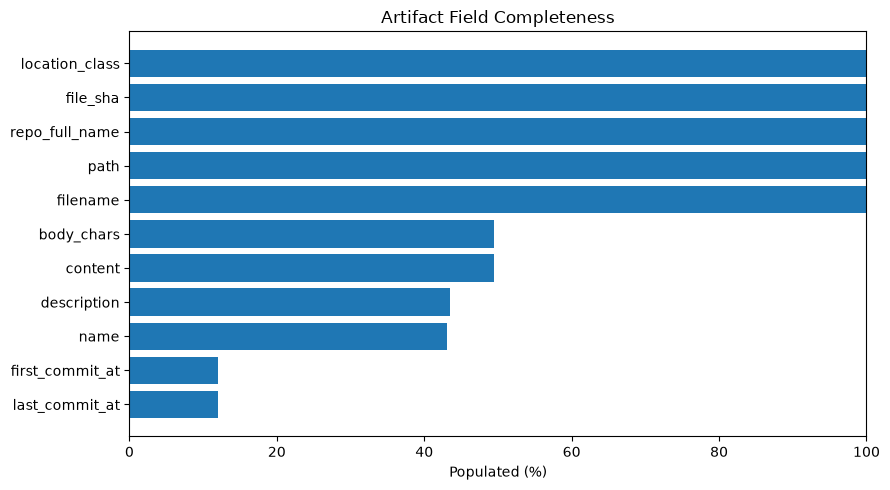

In [198]:
plot_data = field_completeness.sort_values("populated_pct")

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_data["field"],
    plot_data["populated_pct"]
)

ax.set_title("Artifact Field Completeness")
ax.set_xlabel("Populated (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

### 3. Artifact Classification

Examine important categorical fields used to describe artifact structure and metadata.

In [199]:
classification_fields = [
    "frontmatter_valid",
    "location_class",
    "filename",
    "dedup_primary",
    "has_scripts",
    "has_references"
]

for field in classification_fields:
    print(f"\n{field}")

    result = conn.sql(f"""
        SELECT
            {field},
            COUNT(*) AS artifact_count,
            ROUND(
                COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
                2
            ) AS percentage
        FROM artifacts
        GROUP BY {field}
        ORDER BY artifact_count DESC
    """).df()

    display(result)


frontmatter_valid


,frontmatter_valid,artifact_count,percentage
0,<NA>,1916788,50.48
1,1,1627753,42.87
2,0,252576,6.65



location_class


,location_class,artifact_count,percentage
0,skills-dir,2102053,55.36
1,other,1321412,34.80
2,canonical,373652,9.84



filename


...

,dedup_primary,artifact_count,percentage
0,0,1919136,50.54
1,1,1877981,49.46



has_scripts


,has_scripts,artifact_count,percentage
0,<NA>,1918320,50.52
1,0,1664117,43.83
2,1,214680,5.65



has_references


,has_references,artifact_count,percentage
0,<NA>,1918320,50.52
1,0,1392387,36.67
2,1,486410,12.81


### 4. Artifact Body Size Distribution

Examine the size of artifact bodies before deciding whether very small artifacts should be excluded from later analysis.

In [200]:
body_stats = conn.sql("""
    SELECT
        COUNT(body_chars) AS count,
        MIN(body_chars) AS minimum,
        QUANTILE_CONT(body_chars, 0.25) AS p25,
        MEDIAN(body_chars) AS median,
        AVG(body_chars) AS mean,
        QUANTILE_CONT(body_chars, 0.75) AS p75,
        QUANTILE_CONT(body_chars, 0.90) AS p90,
        QUANTILE_CONT(body_chars, 0.95) AS p95,
        QUANTILE_CONT(body_chars, 0.99) AS p99,
        MAX(body_chars) AS maximum
    FROM artifacts
    WHERE body_chars IS NOT NULL
""").df()

display(body_stats)

,count,minimum,p25,median,mean,p75,p90,p95,p99,maximum
0,1880329,0,2130.0,4605.0,6956.07587,8657.0,14833.0,20321.0,41094.44,355781


#### Body Size Distribution

Plot artifact body sizes. The 99th percentile is used as the upper limit so a small number of very large artifacts do not dominate the visualization.

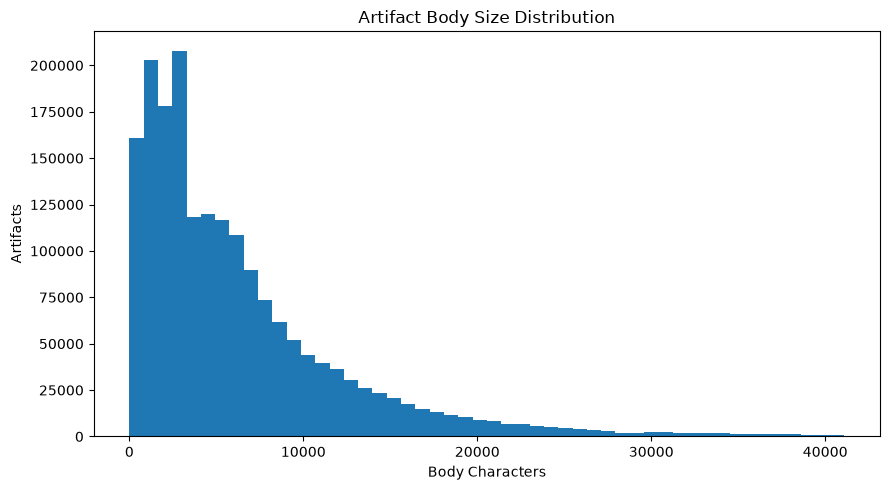

99th percentile: 41,095 characters


In [201]:
body_sizes = conn.sql("""
    SELECT body_chars
    FROM artifacts
    WHERE body_chars IS NOT NULL
      AND body_chars > 0
""").df()

upper_limit = body_sizes["body_chars"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    body_sizes.loc[
        body_sizes["body_chars"] <= upper_limit,
        "body_chars"
    ],
    bins=50
)

ax.set_title("Artifact Body Size Distribution")
ax.set_xlabel("Body Characters")
ax.set_ylabel("Artifacts")

plt.tight_layout()
plt.show()

print(f"99th percentile: {upper_limit:,.0f} characters")

### 5. Skill Name Distribution

Examine how often skill names occur and whether the dataset contains many repeated names.

In [202]:
name_counts = conn.sql("""
    SELECT
        lower(trim(name)) AS name,
        COUNT(*) AS artifact_count
    FROM artifacts
    WHERE name IS NOT NULL
      AND trim(name) <> ''
    GROUP BY lower(trim(name))
    ORDER BY artifact_count DESC
""").df()

print(f"Distinct names: {len(name_counts):,}")
print(f"Names appearing once: {(name_counts['artifact_count'] == 1).sum():,}")
print(f"Names appearing more than once: {(name_counts['artifact_count'] > 1).sum():,}")
print(f"Median artifacts per name: {name_counts['artifact_count'].median():,.0f}")
print(f"Maximum artifacts for one name: {name_counts['artifact_count'].max():,}")

display(name_counts.head(30))

Distinct names: 845,421
Names appearing once: 681,889
Names appearing more than once: 163,532
Median artifacts per name: 1
Maximum artifacts for one name: 3,691


,name,artifact_count
0,code-review,3691
1,skill-creator,2766
2,commit,2464
3,review,2209
4,frontend-design,2163
5,release,1960
6,brainstorming,1423
7,plan,1315
8,systematic-debugging,1309
9,tdd,1270


#### Most Common Skill Names

Show the skill names with the largest number of artifacts.

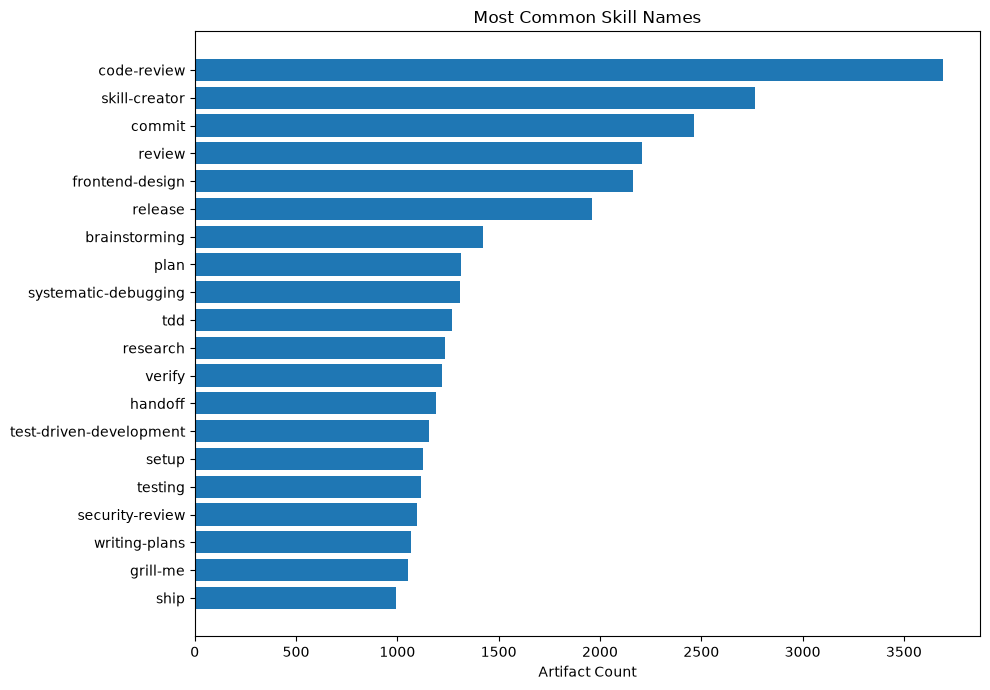

In [203]:
top_names = name_counts.head(20).sort_values("artifact_count")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_names["name"],
    top_names["artifact_count"]
)

ax.set_title("Most Common Skill Names")
ax.set_xlabel("Artifact Count")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Skill Name Frequency Distribution

Show how many skill names occur once, a few times, or many times.

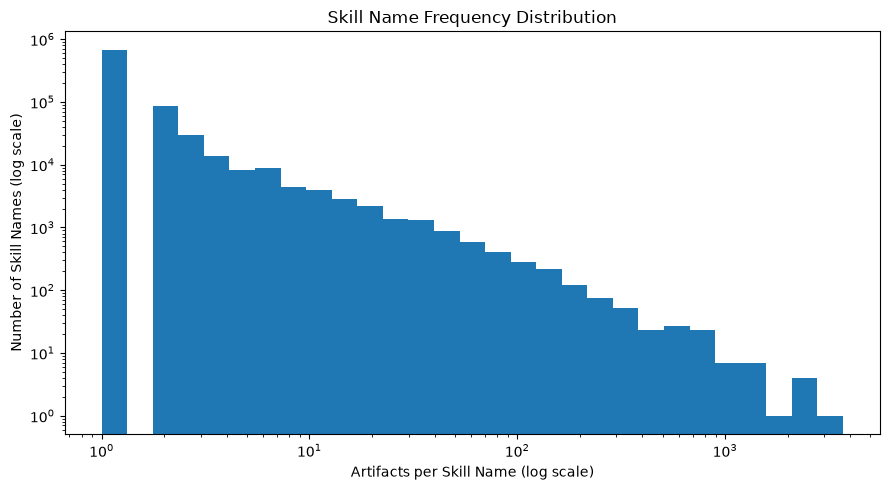

In [244]:
values = name_counts["artifact_count"]

bins = np.logspace(
    np.log10(values.min()),
    np.log10(values.max()),
    30
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    values,
    bins=bins
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Skill Name Frequency Distribution")
ax.set_xlabel("Artifacts per Skill Name (log scale)")
ax.set_ylabel("Number of Skill Names (log scale)")

plt.tight_layout()
plt.show()

### 6. Description Distribution

Examine how often normalized frontmatter descriptions are repeated across artifacts.

In [205]:
description_counts = conn.sql("""
    SELECT
        regexp_replace(
            lower(trim(description)),
            '\\s+',
            ' ',
            'g'
        ) AS normalized_description,
        COUNT(*) AS artifact_count
    FROM artifacts
    WHERE description IS NOT NULL
      AND trim(description) <> ''
    GROUP BY normalized_description
    ORDER BY artifact_count DESC
""").df()

print(f"Distinct descriptions: {len(description_counts):,}")
print(
    f"Descriptions appearing once: "
    f"{(description_counts['artifact_count'] == 1).sum():,}"
)
print(
    f"Descriptions appearing more than once: "
    f"{(description_counts['artifact_count'] > 1).sum():,}"
)
print(
    f"Median artifacts per description: "
    f"{description_counts['artifact_count'].median():,.0f}"
)

display(description_counts.head(30))

Distinct descriptions: 1,292,439
Descriptions appearing once: 1,157,621
Descriptions appearing more than once: 134,818
Median artifacts per description: 1


,normalized_description,artifact_count
0,"owasp repository focused on security guidance,...",679
1,use when you have a spec or requirements for a...,575
2,you must use this before any creative work - c...,513
3,"use when encountering any bug, test failure, o...",484
4,use when executing implementation plans with i...,473
5,"create distinctive, production-grade frontend ...",472
6,"use when creating new skills, editing existing...",437
7,guide for creating effective skills. this skil...,435
8,>,423
9,developer task helper.,418


#### Most Common Descriptions

Show the normalized descriptions that occur most frequently in the dataset.

In [206]:
display(description_counts.head(30))

,normalized_description,artifact_count
0,"owasp repository focused on security guidance,...",679
1,use when you have a spec or requirements for a...,575
2,you must use this before any creative work - c...,513
3,"use when encountering any bug, test failure, o...",484
4,use when executing implementation plans with i...,473
5,"create distinctive, production-grade frontend ...",472
6,"use when creating new skills, editing existing...",437
7,guide for creating effective skills. this skil...,435
8,>,423
9,developer task helper.,418


#### Description Frequency Distribution

Show how frequently descriptions are repeated throughout the dataset.

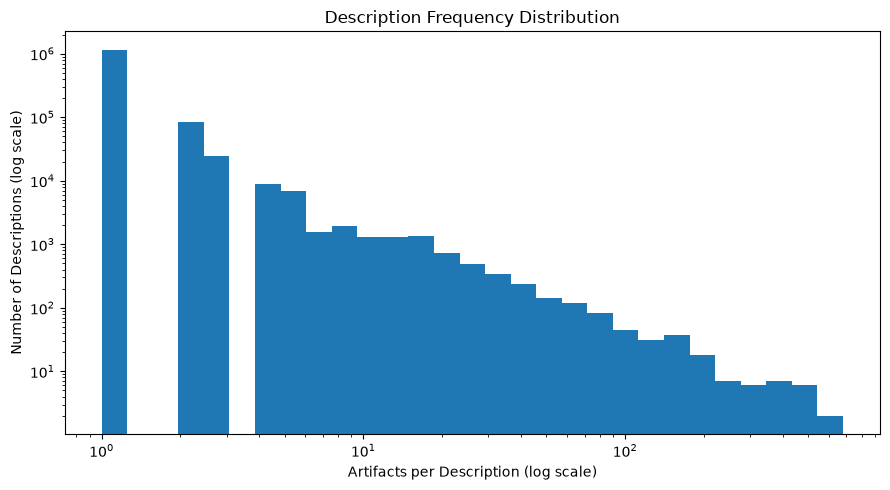

In [245]:
values = description_counts["artifact_count"]

bins = np.logspace(
    np.log10(values.min()),
    np.log10(values.max()),
    30
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    values,
    bins=bins
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Description Frequency Distribution")
ax.set_xlabel("Artifacts per Description (log scale)")
ax.set_ylabel("Number of Descriptions (log scale)")

plt.tight_layout()
plt.show()

### 7. Repository Distribution

Examine how artifacts are distributed across repositories.

In [208]:
repo_counts = conn.sql("""
    SELECT
        repo_full_name,
        COUNT(*) AS artifact_count
    FROM artifacts
    WHERE repo_full_name IS NOT NULL
      AND trim(repo_full_name) <> ''
    GROUP BY repo_full_name
    ORDER BY artifact_count DESC
""").df()

print(f"Distinct repositories: {len(repo_counts):,}")
print(
    f"Median artifacts per repository: "
    f"{repo_counts['artifact_count'].median():,.0f}"
)
print(
    f"Mean artifacts per repository: "
    f"{repo_counts['artifact_count'].mean():,.2f}"
)
print(
    f"Maximum artifacts in one repository: "
    f"{repo_counts['artifact_count'].max():,}"
)

display(repo_counts.head(30))

Distinct repositories: 282,200
Median artifacts per repository: 2
Mean artifacts per repository: 13.46
Maximum artifacts in one repository: 172,267


,repo_full_name,artifact_count
0,majiayu000/claude-skill-registry-data,172267
1,David-Li0406/meta-skill-evloving,110654
2,NeuralBlitz/ncx,63128
3,gabrielmoreira/agent-skills-mirror,60655
4,NeuralBlitz/buggy,30308
5,majiayu000/claude-skill-registry,28460
6,dvcrn/openclaw-skills-marketplace,22669
7,Klotzkette/claude-fuer-deutsches-recht,21955
8,tools-only/X-Skills,21471
9,ahmedfawzy8866/arc,18603


#### Largest Repositories

Show the repositories containing the greatest number of artifacts.

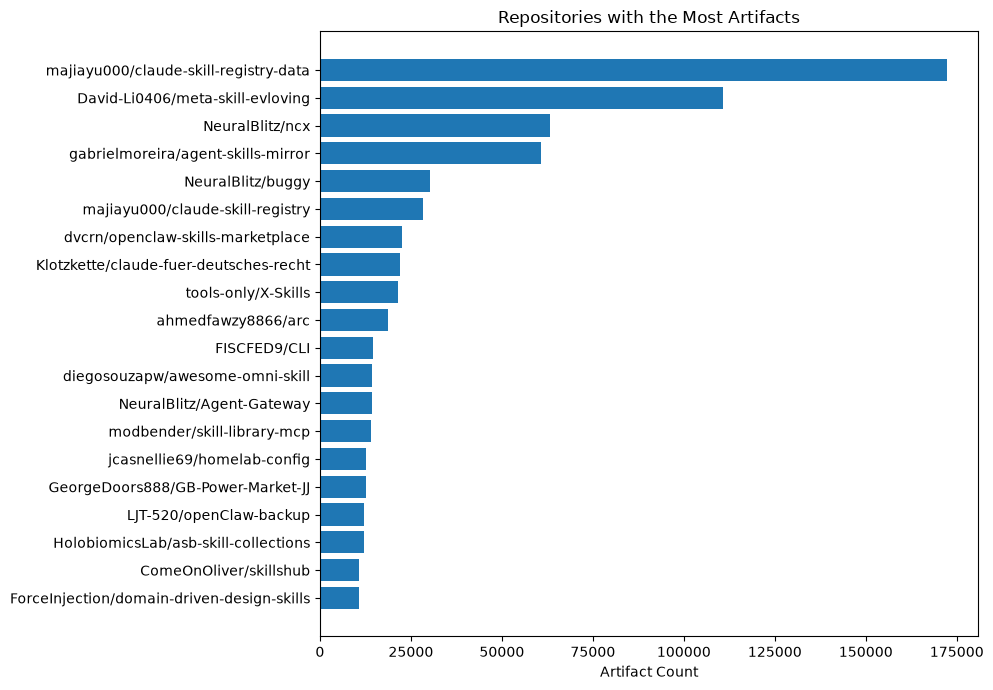

In [209]:
top_repos = repo_counts.head(20).sort_values("artifact_count")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_repos["repo_full_name"],
    top_repos["artifact_count"]
)

ax.set_title("Repositories with the Most Artifacts")
ax.set_xlabel("Artifact Count")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Repository Concentration

Measure how much of the dataset is contained in the largest repositories.

In [210]:
repository_concentration = []

for n in [1, 5, 10, 100]:
    artifact_count = repo_counts.head(n)["artifact_count"].sum()

    repository_concentration.append({
        "top_repositories": n,
        "artifact_count": artifact_count,
        "percentage_of_dataset": artifact_count / total_artifacts * 100
    })

repository_concentration = pd.DataFrame(repository_concentration)

display(repository_concentration)

,top_repositories,artifact_count,percentage_of_dataset
0,1,172267,4.536784
1,5,437012,11.509048
2,10,550170,14.489151
3,100,1064994,28.047437


#### Artifacts per Repository

Show the overall distribution of artifact counts across repositories.

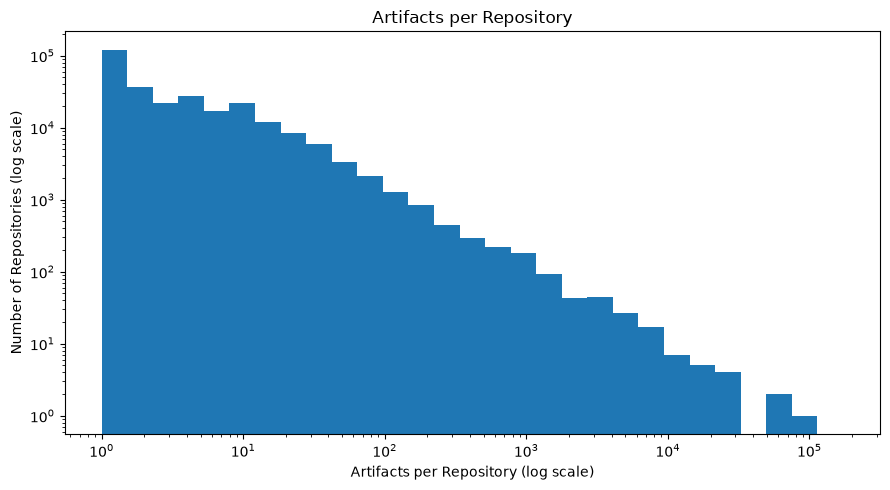

In [246]:
values = repo_counts["artifact_count"]

bins = np.logspace(
    np.log10(values.min()),
    np.log10(values.max()),
    30
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    values,
    bins=bins
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Artifacts per Repository")
ax.set_xlabel("Artifacts per Repository (log scale)")
ax.set_ylabel("Number of Repositories (log scale)")

plt.tight_layout()
plt.show()

### 8. Path, Directory, and Location Distribution

Examine where artifact files are located. Directory names are derived from the parent directory in `path`.

In [212]:
location_counts = conn.sql("""
    SELECT
        location_class,
        COUNT(*) AS artifact_count
    FROM artifacts
    GROUP BY location_class
    ORDER BY artifact_count DESC
""").df()

display(location_counts)

,location_class,artifact_count
0,skills-dir,2102053
1,other,1321412
2,canonical,373652


#### Filename Distribution

Show the most common filenames used for artifacts.

In [213]:
filename_counts = conn.sql("""
    SELECT
        filename,
        COUNT(*) AS artifact_count
    FROM artifacts
    GROUP BY filename
    ORDER BY artifact_count DESC
    LIMIT 30
""").df()

display(filename_counts)

,filename,artifact_count
0,SKILL.md,3742828
1,skill.md,49314
2,Skill.md,3530
3,SKILL.MD,1426
4,skill.MD,6
5,Skill.MD,4
6,SKIll.md,3
7,SkILL.MD,2
8,SkILL.md,1
9,sKILL.md,1


#### Parent Directory Distribution

Derive the immediate parent directory from `path` and show the most common directory names.

In [214]:
directory_counts = conn.sql("""
    SELECT
        lower(trim(
            regexp_extract(
                path,
                '([^/]+)/[^/]+$',
                1
            )
        )) AS derived_skill_dir,
        COUNT(*) AS artifact_count
    FROM artifacts
    WHERE path IS NOT NULL
      AND trim(path) <> ''
    GROUP BY derived_skill_dir
    HAVING derived_skill_dir <> ''
    ORDER BY artifact_count DESC
    LIMIT 30
""").df()

display(directory_counts)

,derived_skill_dir,artifact_count
0,skill-creator,9275
1,frontend-design,6822
2,code-review,5937
3,quickstart,5897
4,skill,3991
5,brainstorming,3922
6,systematic-debugging,3816
7,review,3606
8,commit,3594
9,pdf,3467


#### Artifact Location Classes

Visualize how artifacts are distributed across location classifications.

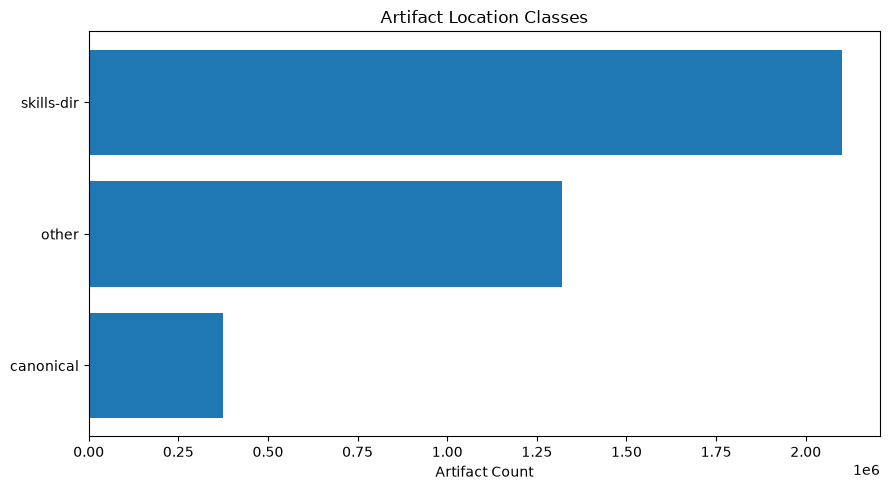

In [215]:
plot_locations = location_counts.iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_locations["location_class"].astype(str),
    plot_locations["artifact_count"]
)

ax.set_title("Artifact Location Classes")
ax.set_xlabel("Artifact Count")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 9. Artifact Timeline

Examine the available commit-history range and the distribution of first observed artifact commits over time. Commit history is available for only a subset of artifacts.

In [216]:
date_stats = conn.sql("""
    SELECT
        COUNT(*) AS total_artifacts,

        COUNT_IF(
            TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
        ) AS first_commit_present,

        ROUND(
            COUNT_IF(
                TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
            ) * 100.0 / COUNT(*),
            2
        ) AS first_commit_pct,

        COUNT_IF(
            TRY_CAST(last_commit_at AS TIMESTAMP) IS NOT NULL
        ) AS last_commit_present,

        ROUND(
            COUNT_IF(
                TRY_CAST(last_commit_at AS TIMESTAMP) IS NOT NULL
            ) * 100.0 / COUNT(*),
            2
        ) AS last_commit_pct,

        MIN(
            TRY_CAST(first_commit_at AS TIMESTAMP)
        ) AS earliest_first_commit,

        MAX(
            TRY_CAST(first_commit_at AS TIMESTAMP)
        ) AS latest_first_commit,

        MIN(
            TRY_CAST(last_commit_at AS TIMESTAMP)
        ) AS earliest_last_commit,

        MAX(
            TRY_CAST(last_commit_at AS TIMESTAMP)
        ) AS latest_last_commit

    FROM artifacts
""").df()

display(date_stats)

,total_artifacts,first_commit_present,first_commit_pct,last_commit_present,last_commit_pct,earliest_first_commit,latest_first_commit,earliest_last_commit,latest_last_commit
0,3797117,458548.0,12.08,458548.0,12.08,2014-06-30 09:10:04,2026-07-23 18:01:48,2000-01-01,2026-07-23 21:24:27


#### Commit Date Consistency

Check for potentially invalid or inconsistent commit-history timestamps before using them in temporal analysis.

In [243]:
commit_date_quality = conn.sql("""
    SELECT
        COUNT(*) AS artifacts_with_both_dates,

        COUNT_IF(
            TRY_CAST(last_commit_at AS TIMESTAMP) <
            TRY_CAST(first_commit_at AS TIMESTAMP)
        ) AS last_before_first,

        COUNT_IF(
            TRY_CAST(first_commit_at AS TIMESTAMP) <
            TIMESTAMP '2010-01-01'
        ) AS first_before_2010,

        COUNT_IF(
            TRY_CAST(last_commit_at AS TIMESTAMP) <
            TIMESTAMP '2010-01-01'
        ) AS last_before_2010

    FROM artifacts

    WHERE TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
      AND TRY_CAST(last_commit_at AS TIMESTAMP) IS NOT NULL
""").df()

display(commit_date_quality)

,artifacts_with_both_dates,last_before_first,first_before_2010,last_before_2010
0,458548,34.0,0.0,1.0


Only a small number of records contain inconsistent commit dates. The temporal analyses below use `first_commit_at`, so these `last_commit_at` inconsistencies do not affect the current analysis.

#### First Observed Commits Over Time

Count artifacts by month using their `first_commit_at` timestamp.

In [217]:
artifact_timeline = conn.sql("""
    SELECT
        DATE_TRUNC(
            'month',
            TRY_CAST(first_commit_at AS TIMESTAMP)
        ) AS month,
        COUNT(*) AS artifact_count
    FROM artifacts
    WHERE TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
    GROUP BY month
    ORDER BY month
""").df()

display(artifact_timeline.head())

,month,artifact_count
0,2014-06-01,1
1,2017-07-01,1
2,2017-12-01,1
3,2018-03-01,1
4,2018-05-01,2


#### Artifact Timeline Visualization

Visualize first observed artifact commits for the subset of artifacts with available commit-history metadata.

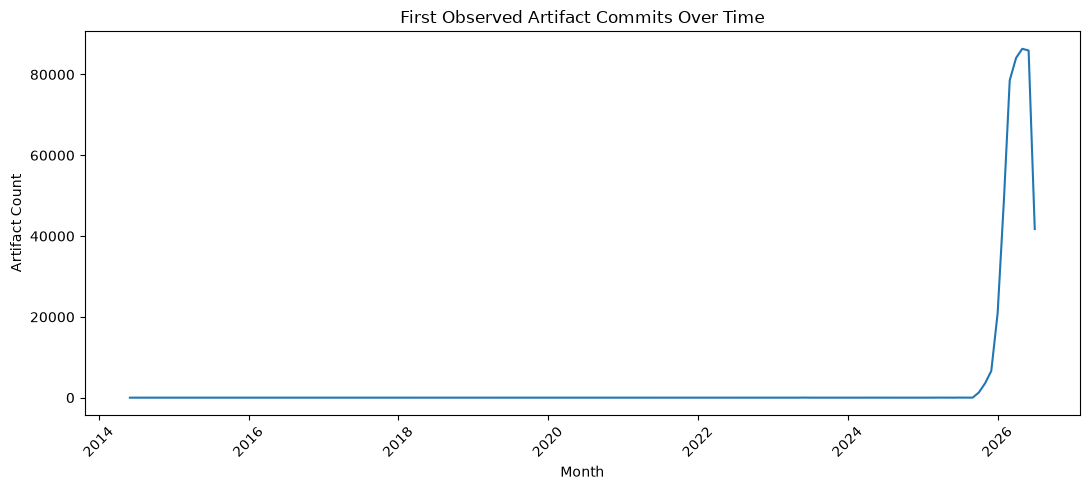

In [218]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    artifact_timeline["month"],
    artifact_timeline["artifact_count"]
)

ax.set_title("First Observed Artifact Commits Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Artifact Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. Duplicate Characteristics

Examine the dataset's existing `dedup_primary` classification before using it as an analysis filter.

In [219]:
dedup_summary = conn.sql("""
    SELECT
        COUNT(*) AS total_artifacts,
        SUM(
            CASE WHEN dedup_primary = 1 THEN 1 ELSE 0 END
        ) AS primary_artifacts,
        SUM(
            CASE WHEN dedup_primary = 0 THEN 1 ELSE 0 END
        ) AS non_primary_artifacts
    FROM artifacts
""").df()

dedup_summary["primary_pct"] = (
    dedup_summary["primary_artifacts"]
    / dedup_summary["total_artifacts"]
    * 100
)

display(dedup_summary)

,total_artifacts,primary_artifacts,non_primary_artifacts,primary_pct
0,3797117,1877981.0,1919136.0,49.458076


#### Deduplication and Metadata Availability

Compare primary and non-primary artifacts to determine whether metadata availability is associated with the dataset's deduplication process.

In [220]:
dedup_metadata = conn.sql("""
    SELECT
        dedup_primary,

        COUNT(*) AS artifact_count,

        COUNT_IF(content_fetched = 1) AS content_fetched,

        COUNT_IF(content IS NOT NULL) AS content_present,

        COUNT_IF(frontmatter_valid IS NOT NULL) AS frontmatter_evaluated,

        COUNT_IF(
            name IS NOT NULL
            AND trim(name) <> ''
        ) AS name_present,

        COUNT_IF(
            description IS NOT NULL
            AND trim(description) <> ''
        ) AS description_present,

        COUNT_IF(history_fetched = 1) AS history_fetched,

        COUNT_IF(
            TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
        ) AS first_commit_present,

        COUNT_IF(composition_fetched = 1) AS composition_fetched

    FROM artifacts
    GROUP BY dedup_primary
    ORDER BY dedup_primary DESC
""").df()

display(dedup_metadata)

,dedup_primary,artifact_count,content_fetched,content_present,frontmatter_evaluated,name_present,description_present,history_fetched,first_commit_present,composition_fetched
0,1,1877981,1877981.0,1877981.0,1877981.0,1633503.0,1648761.0,458137.0,458137.0,1876437.0
1,0,1919136,2367.0,2348.0,2348.0,2065.0,2069.0,411.0,411.0,2360.0


In [221]:
dedup_metadata_pct = dedup_metadata.copy()

metadata_columns = [
    "content_fetched",
    "content_present",
    "frontmatter_evaluated",
    "name_present",
    "description_present",
    "history_fetched",
    "first_commit_present",
    "composition_fetched"
]

for column in metadata_columns:
    dedup_metadata_pct[column] = (
        dedup_metadata_pct[column]
        / dedup_metadata_pct["artifact_count"]
        * 100
    )

display(dedup_metadata_pct.round(2))

,dedup_primary,artifact_count,content_fetched,content_present,frontmatter_evaluated,name_present,description_present,history_fetched,first_commit_present,composition_fetched
0,1,1877981,100.00,100.00,100.00,86.98,87.79,24.40,24.40,99.92
1,0,1919136,0.12,0.12,0.12,0.11,0.11,0.02,0.02,0.12


## Exploratory Analysis

### 11. Quality Filter Impact

Measure how proposed quality filters reduce the artifact population before using them in later analysis.

In [222]:
filter_counts = conn.sql("""
    SELECT '1. All artifacts' AS stage, COUNT(*) AS artifact_count
    FROM artifacts

    UNION ALL

    SELECT '2. Primary deduplicated artifacts', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1

    UNION ALL

    SELECT '3. Valid frontmatter', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1

    UNION ALL

    SELECT '4. Canonical or skills directory', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')

    UNION ALL

    SELECT '5. SKILL.md filename', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')

    UNION ALL

    SELECT '6. Body longer than 50 characters', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')
      AND body_chars > 50

    UNION ALL

    SELECT '7. Content present', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')
      AND body_chars > 50
      AND content IS NOT NULL

    UNION ALL

    SELECT '8. Name present', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')
      AND body_chars > 50
      AND content IS NOT NULL
      AND name IS NOT NULL
      AND trim(name) <> ''

    UNION ALL

    SELECT '9. Description present', COUNT(*)
    FROM artifacts
    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')
      AND body_chars > 50
      AND content IS NOT NULL
      AND name IS NOT NULL
      AND trim(name) <> ''
      AND description IS NOT NULL
      AND trim(description) <> ''
""").df()

filter_counts["retained_from_all_pct"] = (
    filter_counts["artifact_count"]
    / filter_counts.iloc[0]["artifact_count"]
    * 100
)

filter_counts["retained_from_previous_pct"] = (
    filter_counts["artifact_count"]
    / filter_counts["artifact_count"].shift(1)
    * 100
)

filter_counts.loc[0, "retained_from_previous_pct"] = 100.0

display(filter_counts)

,stage,artifact_count,retained_from_all_pct,retained_from_previous_pct
0,1. All artifacts,3797117,100.000000,100.000000
1,2. Primary deduplicated artifacts,1877981,49.458076,49.458076
2,3. Valid frontmatter,1625701,42.814088,86.566424
3,4. Canonical or skills directory,1150790,30.306941,70.787310
4,5. SKILL.md filename,1150390,30.296406,99.965241
5,6. Body longer than 50 characters,1146188,30.185744,99.634733
6,7. Content present,1146188,30.185744,100.000000
7,8. Name present,1146188,30.185744,100.000000
8,9. Description present,1146188,30.185744,100.000000


#### Filter Attrition

Visualize how many artifacts remain after each proposed quality filter.

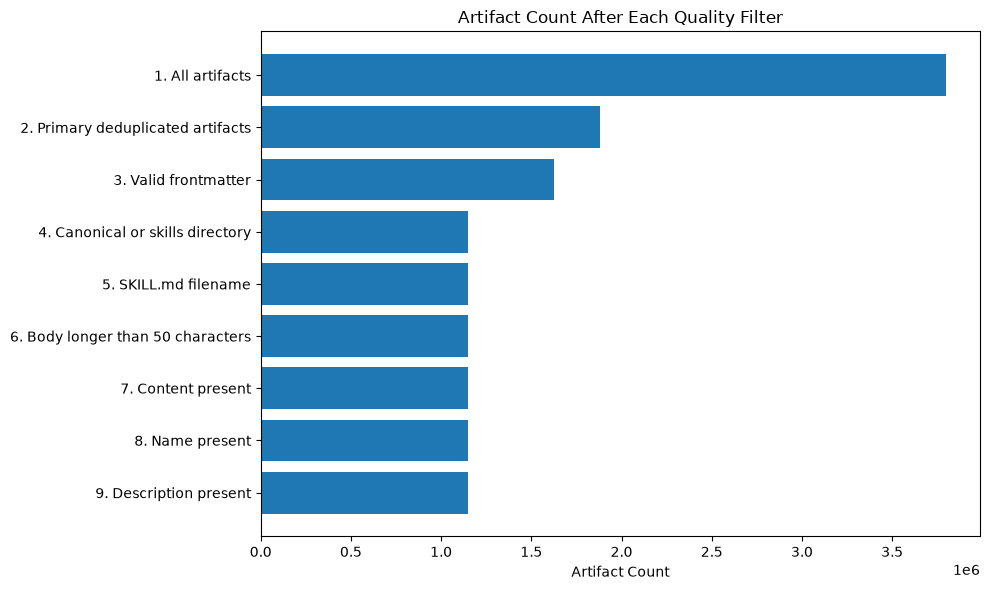

In [223]:
plot_filter_counts = filter_counts.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_filter_counts["stage"],
    plot_filter_counts["artifact_count"]
)

ax.set_title("Artifact Count After Each Quality Filter")
ax.set_xlabel("Artifact Count")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Commit History Coverage

Commit history is not required for the core analysis population. Measure how much of the filtered population can support additional chronological analysis.

In [224]:
history_coverage = conn.sql("""
    SELECT
        COUNT(*) AS filtered_artifacts,

        COUNT_IF(
            TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
        ) AS artifacts_with_history,

        ROUND(
            COUNT_IF(
                TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
            ) * 100.0 / COUNT(*),
            2
        ) AS history_coverage_pct

    FROM artifacts

    WHERE dedup_primary = 1
      AND frontmatter_valid = 1
      AND location_class IN ('canonical', 'skills-dir')
      AND filename IN ('SKILL.md', 'skill.md')
      AND body_chars > 50
      AND content IS NOT NULL
      AND name IS NOT NULL
      AND trim(name) <> ''
      AND description IS NOT NULL
      AND trim(description) <> ''
""").df()

display(history_coverage)

,filtered_artifacts,artifacts_with_history,history_coverage_pct
0,1146188,346019.0,30.19


#### Analysis Population

Define the common quality filters used for the remaining exploratory analysis.

In [225]:
BASE_FILTER = """
    dedup_primary = 1
    AND frontmatter_valid = 1
    AND location_class IN ('canonical', 'skills-dir')
    AND filename IN ('SKILL.md', 'skill.md')
    AND body_chars > 50
    AND content IS NOT NULL
    AND name IS NOT NULL
    AND trim(name) <> ''
"""

print("Base analysis filter defined.")

Base analysis filter defined.


### 12. Name and Parent Directory Agreement

Derive the immediate parent directory from `path` and test whether it provides information beyond the skill name.

In [226]:
name_dir_summary = conn.sql(f"""
    WITH filtered AS (
        SELECT
            name,
            regexp_extract(
                path,
                '([^/]+)/[^/]+$',
                1
            ) AS derived_skill_dir
        FROM artifacts
        WHERE {BASE_FILTER}
          AND path IS NOT NULL
    )
    SELECT
        COUNT(*) AS artifacts_with_directory,
        SUM(
            CASE
                WHEN lower(trim(name)) =
                     lower(trim(derived_skill_dir))
                THEN 1
                ELSE 0
            END
        ) AS matching_name_dir
    FROM filtered
    WHERE derived_skill_dir <> ''
""").df()

name_dir_summary["match_pct"] = (
    name_dir_summary["matching_name_dir"]
    / name_dir_summary["artifacts_with_directory"]
    * 100
)

display(name_dir_summary)

,artifacts_with_directory,matching_name_dir,match_pct
0,1146188,1068198.0,93.195706


#### Largest Name and Parent Directory Groups

Show whether large skill-name groups remain large after also grouping by the derived parent directory.

In [227]:
name_dir_groups = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            lower(trim(
                regexp_extract(
                    path,
                    '([^/]+)/[^/]+$',
                    1
                )
            )) AS derived_skill_dir
        FROM artifacts
        WHERE {BASE_FILTER}
          AND path IS NOT NULL
    )
    SELECT
        name,
        derived_skill_dir,
        COUNT(*) AS artifact_count
    FROM filtered
    WHERE derived_skill_dir <> ''
    GROUP BY
        name,
        derived_skill_dir
    HAVING COUNT(*) > 1
    ORDER BY artifact_count DESC
    LIMIT 30
""").df()

display(name_dir_groups)

,name,derived_skill_dir,artifact_count
0,code-review,code-review,2966
1,commit,commit,2155
2,skill-creator,skill-creator,1958
3,release,release,1838
4,review,review,1831
5,frontend-design,frontend-design,1738
6,verify,verify,1129
7,brainstorming,brainstorming,1117
8,plan,plan,1049
9,setup,setup,1030


### 13. Description Fragmentation Within Skill Names

Examine whether normalized descriptions divide large same-name artifact groups into smaller groups.

In [228]:
description_fragmentation = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
    ),
    families AS (
        SELECT
            name,
            normalized_description,
            COUNT(*) AS family_size
        FROM filtered
        GROUP BY
            name,
            normalized_description
    )
    SELECT
        name,
        SUM(family_size) AS artifact_count,
        COUNT(*) AS description_count,
        MAX(family_size) AS largest_description_group,
        ROUND(
            MAX(family_size) * 100.0 / SUM(family_size),
            2
        ) AS largest_group_pct
    FROM families
    GROUP BY name
    ORDER BY artifact_count DESC
""").df()

display(description_fragmentation.head(30))

,name,artifact_count,description_count,largest_description_group,largest_group_pct
0,code-review,3029.0,2660,49,1.62
1,commit,2179.0,1904,23,1.06
2,skill-creator,2064.0,1077,304,14.73
3,review,1903.0,1642,41,2.15
4,release,1852.0,1745,6,0.32
5,frontend-design,1800.0,894,360,20.00
6,brainstorming,1146.0,609,375,32.72
7,verify,1137.0,1096,5,0.44
8,plan,1060.0,947,20,1.89
9,setup,1046.0,925,16,1.53


#### Skill Name Groups vs. Largest Description Groups

Compare the total artifacts sharing a skill name with the largest group that also shares the same description.

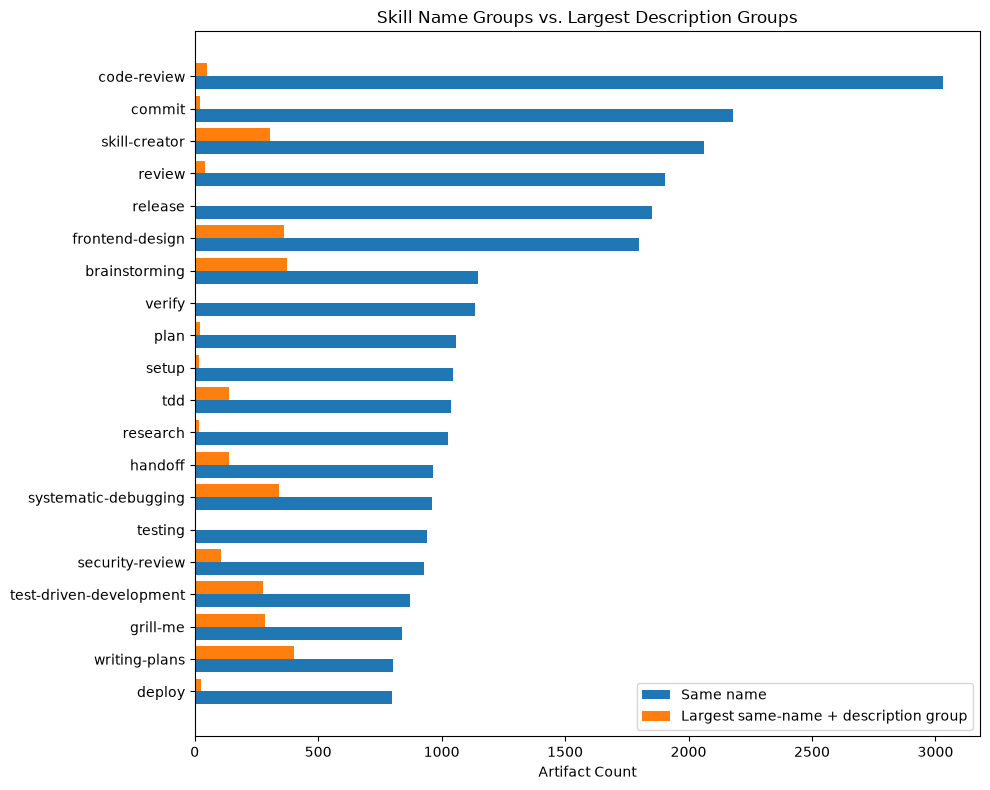

In [229]:
plot_data = (
    description_fragmentation
    .head(20)
    .sort_values("artifact_count")
    .copy()
)

y = np.arange(len(plot_data))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    y - bar_height / 2,
    plot_data["artifact_count"],
    height=bar_height,
    label="Same name"
)

ax.barh(
    y + bar_height / 2,
    plot_data["largest_description_group"],
    height=bar_height,
    label="Largest same-name + description group"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_data["name"])

ax.set_title("Skill Name Groups vs. Largest Description Groups")
ax.set_xlabel("Artifact Count")
ax.set_ylabel("")
ax.legend()

plt.tight_layout()
plt.show()

### 14. Candidate Family Size Distribution

Treat artifacts sharing a normalized name and description as provisional candidate groups and examine their sizes.

In [230]:
candidate_families = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
    )
    SELECT
        name,
        normalized_description,
        COUNT(*) AS family_size
    FROM filtered
    GROUP BY
        name,
        normalized_description
    HAVING COUNT(*) > 1
    ORDER BY family_size DESC
""").df()

print(f"Candidate families: {len(candidate_families):,}")
print(f"Median family size: {candidate_families['family_size'].median():,.0f}")
print(f"75th percentile: {candidate_families['family_size'].quantile(.75):,.0f}")
print(f"90th percentile: {candidate_families['family_size'].quantile(.90):,.0f}")
print(f"95th percentile: {candidate_families['family_size'].quantile(.95):,.0f}")
print(f"Maximum family size: {candidate_families['family_size'].max():,}")

display(candidate_families.head(30))

Candidate families: 77,959
Median family size: 2
75th percentile: 3
90th percentile: 5
95th percentile: 9
Maximum family size: 404


,name,normalized_description,family_size
0,writing-plans,use when you have a spec or requirements for a...,404
1,brainstorming,you must use this before any creative work - c...,375
2,frontend-design,"create distinctive, production-grade frontend ...",360
3,subagent-driven-development,use when executing implementation plans with i...,343
4,systematic-debugging,"use when encountering any bug, test failure, o...",341
5,writing-skills,"use when creating new skills, editing existing...",319
6,skill-creator,guide for creating effective skills. this skil...,304
7,impeccable,"use when the user wants to design, redesign, s...",302
8,grill-me,interview the user relentlessly about a plan o...,284
9,test-driven-development,"use when implementing any feature or bugfix, b...",278


#### Candidate Family Size Distribution

Group candidate-family sizes into ranges to show how many families are small and how many belong to the long tail of larger groups.

,family_size,family_count,percentage
0,2,53541,68.678408
1,3–5,16765,21.504894
2,6–10,4861,6.235329
3,11–25,2167,2.779666
4,26–50,378,0.484870
5,51–100,161,0.206519
6,101–250,76,0.097487
7,251+,10,0.012827


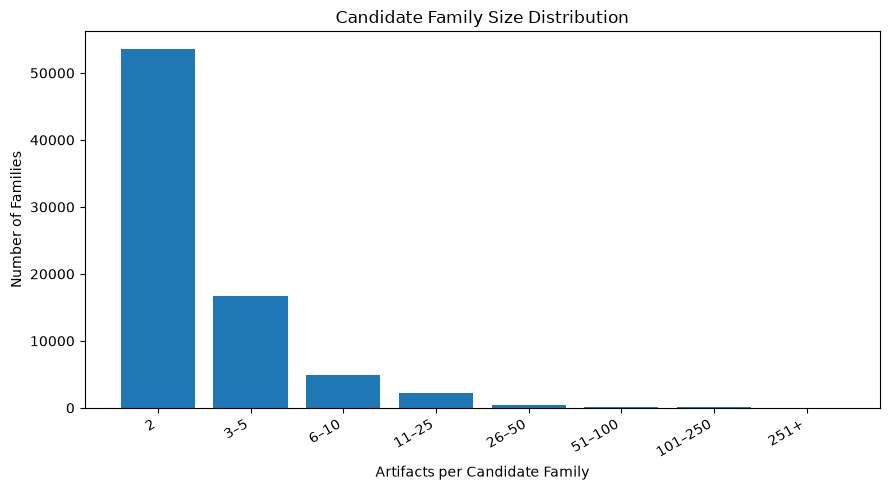

In [248]:
family_size_buckets = pd.cut(
    candidate_families["family_size"],
    bins=[1, 2, 5, 10, 25, 50, 100, 250, float("inf")],
    labels=[
        "2",
        "3–5",
        "6–10",
        "11–25",
        "26–50",
        "51–100",
        "101–250",
        "251+"
    ],
    include_lowest=True
)

family_size_distribution = (
    family_size_buckets
    .value_counts(sort=False)
    .rename_axis("family_size")
    .reset_index(name="family_count")
)

family_size_distribution["percentage"] = (
    family_size_distribution["family_count"]
    / family_size_distribution["family_count"].sum()
    * 100
)

display(family_size_distribution)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    family_size_distribution["family_size"].astype(str),
    family_size_distribution["family_count"]
)

ax.set_title("Candidate Family Size Distribution")
ax.set_xlabel("Artifacts per Candidate Family")
ax.set_ylabel("Number of Families")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 15. Repository Dispersion Within Candidate Families

Examine how widely provisional candidate families are distributed across repositories.

In [232]:
family_repositories = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description,
            repo_full_name
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
          AND repo_full_name IS NOT NULL
    )
    SELECT
        name,
        normalized_description,
        COUNT(*) AS artifact_count,
        COUNT(DISTINCT repo_full_name) AS repository_count,
        COUNT(*)::DOUBLE
            / COUNT(DISTINCT repo_full_name) AS artifacts_per_repository
    FROM filtered
    GROUP BY
        name,
        normalized_description
    HAVING COUNT(*) > 1
    ORDER BY artifact_count DESC
""").df()

display(family_repositories.head(30))

,name,normalized_description,artifact_count,repository_count,artifacts_per_repository
0,writing-plans,use when you have a spec or requirements for a...,404,396,1.020202
1,brainstorming,you must use this before any creative work - c...,375,369,1.016260
2,frontend-design,"create distinctive, production-grade frontend ...",360,340,1.058824
3,subagent-driven-development,use when executing implementation plans with i...,343,329,1.042553
4,systematic-debugging,"use when encountering any bug, test failure, o...",341,334,1.020958
5,writing-skills,"use when creating new skills, editing existing...",319,303,1.052805
6,skill-creator,guide for creating effective skills. this skil...,304,284,1.070423
7,impeccable,"use when the user wants to design, redesign, s...",302,231,1.307359
8,grill-me,interview the user relentlessly about a plan o...,284,282,1.007092
9,test-driven-development,"use when implementing any feature or bugfix, b...",278,270,1.029630


#### Artifact Count vs. Repository Count

Compare the size of each candidate family with the number of repositories in which it appears.

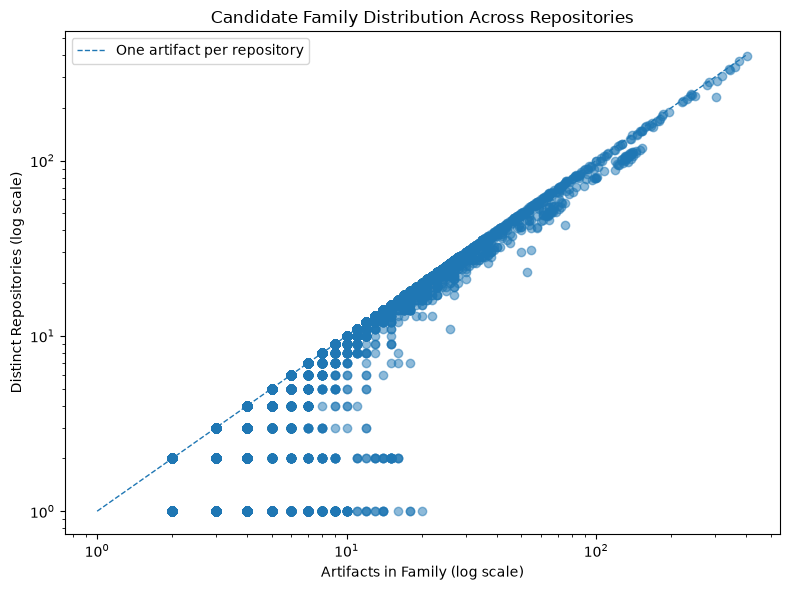

In [233]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    family_repositories["artifact_count"],
    family_repositories["repository_count"],
    alpha=0.5
)

max_value = max(
    family_repositories["artifact_count"].max(),
    family_repositories["repository_count"].max()
)

ax.plot(
    [1, max_value],
    [1, max_value],
    linestyle="--",
    linewidth=1,
    label="One artifact per repository"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Candidate Family Distribution Across Repositories")
ax.set_xlabel("Artifacts in Family (log scale)")
ax.set_ylabel("Distinct Repositories (log scale)")
ax.legend()

plt.tight_layout()
plt.show()

### 16. Body Size Variation Within Candidate Families

Examine whether artifacts sharing the same name and description also tend to have similar body lengths.

In [234]:
family_body_sizes = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description,
            body_chars
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
    )
    SELECT
        name,
        normalized_description,
        COUNT(*) AS family_size,
        MIN(body_chars) AS min_body_chars,
        MEDIAN(body_chars) AS median_body_chars,
        MAX(body_chars) AS max_body_chars,
        MIN(body_chars)::DOUBLE
            / NULLIF(MAX(body_chars), 0) AS size_ratio
    FROM filtered
    GROUP BY
        name,
        normalized_description
    HAVING COUNT(*) > 1
    ORDER BY family_size DESC
""").df()

display(family_body_sizes.head(30))

,name,normalized_description,family_size,min_body_chars,median_body_chars,max_body_chars,size_ratio
0,writing-plans,use when you have a spec or requirements for a...,404,134,5931.5,27338,0.004902
1,brainstorming,you must use this before any creative work - c...,375,201,10152.0,30057,0.006687
2,frontend-design,"create distinctive, production-grade frontend ...",360,1608,3983.0,43830,0.036687
3,subagent-driven-development,use when executing implementation plans with i...,343,158,12000.0,47330,0.003338
4,systematic-debugging,"use when encountering any bug, test failure, o...",341,163,9721.0,24515,0.006649
5,writing-skills,"use when creating new skills, editing existing...",319,129,22374.0,27695,0.004658
6,skill-creator,guide for creating effective skills. this skil...,304,93,17395.0,35252,0.002638
7,impeccable,"use when the user wants to design, redesign, s...",302,2081,18618.0,25255,0.082400
8,grill-me,interview the user relentlessly about a plan o...,284,92,471.5,27035,0.003403
9,test-driven-development,"use when implementing any feature or bugfix, b...",278,151,9791.0,19002,0.007947


#### Body Size Ratio Summary

Summarize variation in body size across candidate families before considering body length as an additional similarity signal.

In [235]:
body_size_ratio_stats = family_body_sizes["size_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

display(body_size_ratio_stats)

count    77959.000000
mean         0.864119
std          0.225584
min          0.000892
25%          0.837932
50%          0.972328
75%          0.999903
90%          1.000000
95%          1.000000
max          1.000000
Name: size_ratio, dtype: float64

#### Body Size Variation

Plot the ratio of the smallest to largest artifact body within each candidate family. Values near 1 indicate more similar document sizes.

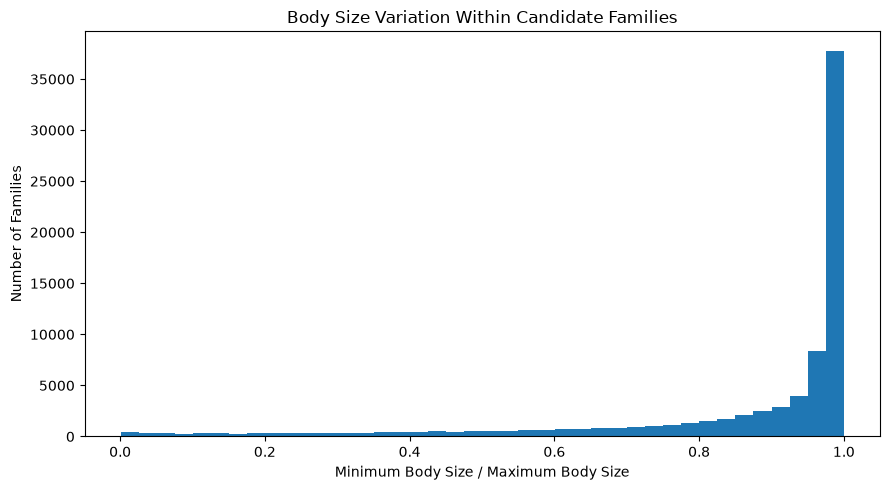

In [236]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    family_body_sizes["size_ratio"].dropna(),
    bins=40
)

ax.set_title("Body Size Variation Within Candidate Families")
ax.set_xlabel("Minimum Body Size / Maximum Body Size")
ax.set_ylabel("Number of Families")

plt.tight_layout()
plt.show()

### 17. Temporal Variation Within Candidate Families

Examine temporal variation for candidate-family artifacts with available commit history. These results apply only to the history-enriched subset and are not required for content-based candidate grouping.

In [237]:
family_time = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description,
            TRY_CAST(first_commit_at AS TIMESTAMP) AS first_commit_ts
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
          AND TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
    )
    SELECT
        name,
        normalized_description,
        COUNT(*) AS family_size,
        MIN(first_commit_ts) AS earliest_commit,
        MAX(first_commit_ts) AS latest_commit,
        DATE_DIFF(
            'day',
            MIN(first_commit_ts),
            MAX(first_commit_ts)
        ) AS span_days
    FROM filtered
    GROUP BY
        name,
        normalized_description
    HAVING COUNT(*) > 1
    ORDER BY family_size DESC
""").df()

display(family_time.head(30))

,name,normalized_description,family_size,earliest_commit,latest_commit,span_days
0,frontend-design,"create distinctive, production-grade frontend ...",125,2025-12-16 19:44:51,2026-06-30 08:38:54,196
1,skill-creator,guide for creating effective skills. this skil...,118,2025-10-21 09:30:07,2026-07-17 14:38:31,269
2,grill-me,interview the user relentlessly about a plan o...,112,2026-03-18 22:38:47,2026-07-08 00:59:18,112
3,openspec-apply-change,implement tasks from an openspec change. use w...,111,2026-01-09 07:51:53,2026-07-17 21:18:46,189
4,writing-plans,use when you have a spec or requirements for a...,106,2025-10-16 14:19:00,2026-07-10 18:42:20,267
5,frontend-design,"create distinctive, production-grade frontend ...",105,2025-11-18 19:21:17,2026-07-10 00:56:36,234
6,brainstorming,you must use this before any creative work - c...,104,2025-10-16 14:19:00,2026-07-16 06:06:06,273
7,openspec-archive-change,archive a completed change in the experimental...,92,2026-01-21 17:17:35,2026-07-09 07:37:33,169
8,speckit-specify,create or update the feature specification fro...,90,2026-04-03 15:22:01,2026-07-17 07:36:10,105
9,vercel-react-best-practices,react and next.js performance optimization gui...,89,2026-01-15 06:49:19,2026-07-14 14:19:39,180


#### Candidate Family Time Span

Show the distribution of time between the earliest and latest observed artifacts in each family.

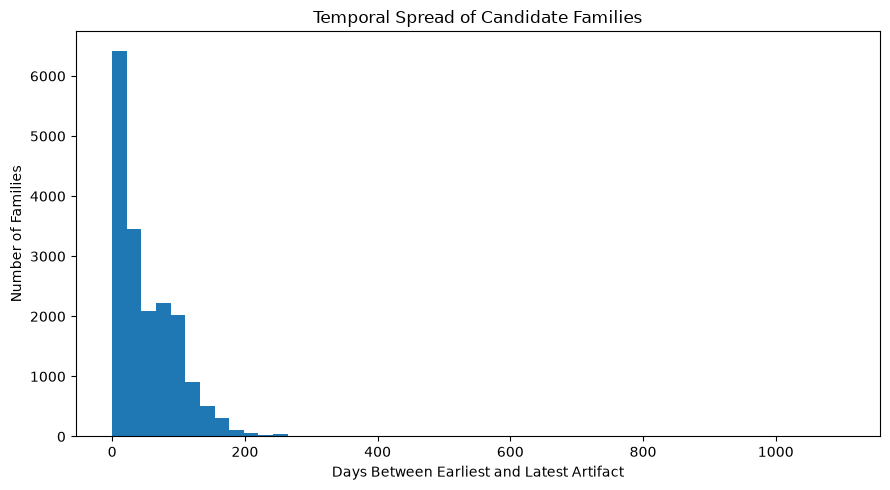

In [238]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    family_time["span_days"],
    bins=50
)

ax.set_title("Temporal Spread of Candidate Families")
ax.set_xlabel("Days Between Earliest and Latest Artifact")
ax.set_ylabel("Number of Families")

plt.tight_layout()
plt.show()

#### Earliest Observed Artifact Ties

Check whether multiple artifacts within a family share the same earliest observed commit timestamp.

In [239]:
earliest_ties = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,
            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description,
            TRY_CAST(first_commit_at AS TIMESTAMP) AS first_commit_ts
        FROM artifacts
        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
          AND TRY_CAST(first_commit_at AS TIMESTAMP) IS NOT NULL
    ),
    earliest AS (
        SELECT
            name,
            normalized_description,
            COUNT(*) AS family_size,
            MIN(first_commit_ts) AS earliest_commit
        FROM filtered
        GROUP BY
            name,
            normalized_description
        HAVING COUNT(*) > 1
    )
    SELECT
        e.name,
        e.normalized_description,
        e.family_size,
        e.earliest_commit,
        COUNT(*) AS artifacts_at_earliest_commit
    FROM earliest AS e
    JOIN filtered AS f
      ON f.name = e.name
     AND f.normalized_description = e.normalized_description
     AND f.first_commit_ts = e.earliest_commit
    GROUP BY
        e.name,
        e.normalized_description,
        e.family_size,
        e.earliest_commit
    HAVING COUNT(*) > 1
    ORDER BY
        artifacts_at_earliest_commit DESC,
        family_size DESC
""").df()

print(
    f"Families with multiple artifacts at the earliest timestamp: "
    f"{len(earliest_ties):,}"
)

display(earliest_ties.head(30))

Families with multiple artifacts at the earliest timestamp: 1,359


,name,normalized_description,family_size,earliest_commit,artifacts_at_earliest_commit
0,setup,run initial nanoclaw setup. use when user want...,15,2026-01-31 16:54:24,11
1,career-ops,ai job search command center -- evaluate offer...,17,2026-04-05 06:29:40,10
2,update-nanoclaw,efficiently bring upstream nanoclaw updates in...,16,2026-03-01 21:19:07,9
3,customize,add new capabilities or modify nanoclaw behavi...,12,2026-01-31 16:54:24,9
4,mcp-tool-change,"use when adding, renaming, or changing this ba...",13,2026-07-06 14:47:51,8
5,add-gmail,add gmail integration to nanoclaw. can be conf...,11,2026-02-01 21:51:41,8
6,fastapi-route-change,"use when adding, renaming, or modifying this b...",11,2026-07-06 14:47:51,7
7,polish,"perform a final quality pass fixing alignment,...",7,2026-04-08 22:17:44,7
8,x-integration,x (twitter) integration for nanoclaw. post twe...,10,2026-02-03 22:27:04,6
9,add-karpathy-llm-wiki,add a persistent wiki knowledge base to a nano...,7,2026-04-05 08:25:57,6


### 18. Estimated Pairwise Comparison Workload

Estimate the number of unique artifact pairs that would need to be evaluated under different candidate-grouping strategies. These values represent potential pairwise comparisons, not database records.

In [240]:
comparison_workload = conn.sql(f"""
    WITH filtered AS (
        SELECT
            lower(trim(name)) AS name,

            regexp_replace(
                lower(trim(description)),
                '\\s+',
                ' ',
                'g'
            ) AS normalized_description

        FROM artifacts

        WHERE {BASE_FILTER}
          AND description IS NOT NULL
          AND trim(description) <> ''
    ),

    name_groups AS (
        SELECT
            name,
            COUNT(*) AS n
        FROM filtered
        GROUP BY name
        HAVING COUNT(*) > 1
    ),

    description_groups AS (
        SELECT
            name,
            normalized_description,
            COUNT(*) AS n
        FROM filtered
        GROUP BY
            name,
            normalized_description
        HAVING COUNT(*) > 1
    )

    SELECT
        'Same name: all pairs' AS method,
        SUM(n * (n - 1) / 2) AS candidate_pair_count
    FROM name_groups

    UNION ALL

    SELECT
        'Same name + description: all pairs',
        SUM(n * (n - 1) / 2)
    FROM description_groups

    UNION ALL

    SELECT
        'Name + description: single baseline',
        SUM(n - 1)
    FROM description_groups
""").df()

display(comparison_workload)

name_pairs = comparison_workload.loc[
    comparison_workload["method"] == "Same name: all pairs",
    "candidate_pair_count"
].iloc[0]

description_pairs = comparison_workload.loc[
    comparison_workload["method"] == "Same name + description: all pairs",
    "candidate_pair_count"
].iloc[0]

pair_reduction_pct = (
    1 - description_pairs / name_pairs
) * 100

print(
    f"Reduction from name-only to name + description blocking: "
    f"{pair_reduction_pct:.2f}%"
)

,method,candidate_pair_count
0,Same name: all pairs,40033909.0
1,Same name + description: all pairs,2512725.0
2,Name + description: single baseline,194661.0


Reduction from name-only to name + description blocking: 93.72%


#### Candidate Pair Reduction

Compare the number of candidate pairs produced by each grouping strategy. The single-baseline approach is shown as a hypothetical additional reduction, not as a selected methodology.

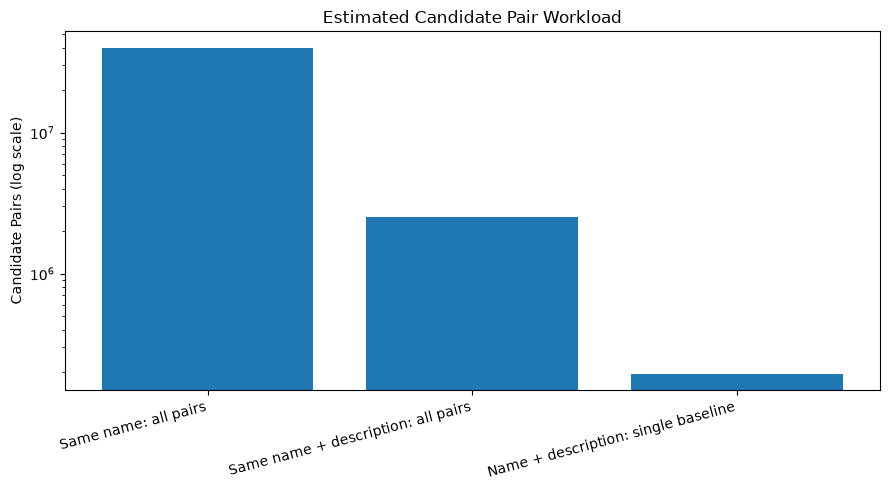

In [241]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    comparison_workload["method"],
    comparison_workload["candidate_pair_count"]
)

ax.set_yscale("log")

ax.set_title("Estimated Candidate Pair Workload")
ax.set_ylabel("Candidate Pairs (log scale)")
ax.set_xlabel("")

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Preliminary Findings

Approximately half of the artifact rows are classified as non-primary duplicates. Metadata enrichment is strongly associated with deduplication status: primary artifacts have complete content coverage, while non-primary artifacts were rarely enriched.

After applying the proposed quality filters, 1,146,188 artifacts remain in the core analysis population. Commit-history metadata is available for only 30.19% of this population, so chronological analysis should be treated as supporting evidence rather than a requirement for candidate identification.

Skill names alone produce large candidate groups. Parent-directory names provide little additional discrimination because 93.2% match the skill name.

Combining normalized skill name and description reduces the candidate pair space from approximately 40.0 million to 2.5 million pairs, a 93.72% reduction. Most resulting candidate families are small, with approximately 96% containing 10 or fewer artifacts.

Candidate families are commonly distributed across many repositories, and most families contain artifacts with very similar body lengths. However, some large families contain substantial body-size variation, so matching names and descriptions do not establish equivalence or lineage.

Content similarity is therefore still needed to validate candidate relationships. Body size and available commit history may provide additional supporting signals.